In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv(
    r"C:\Users\adith\Downloads\archive\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

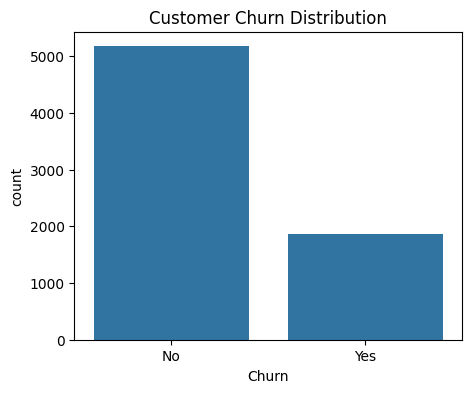

In [10]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.show()

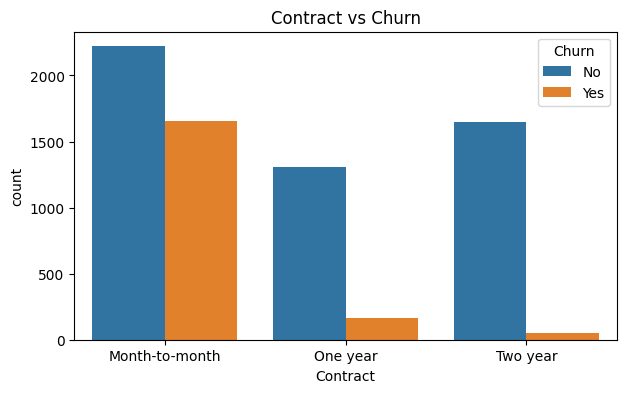

In [11]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract vs Churn")
plt.show()

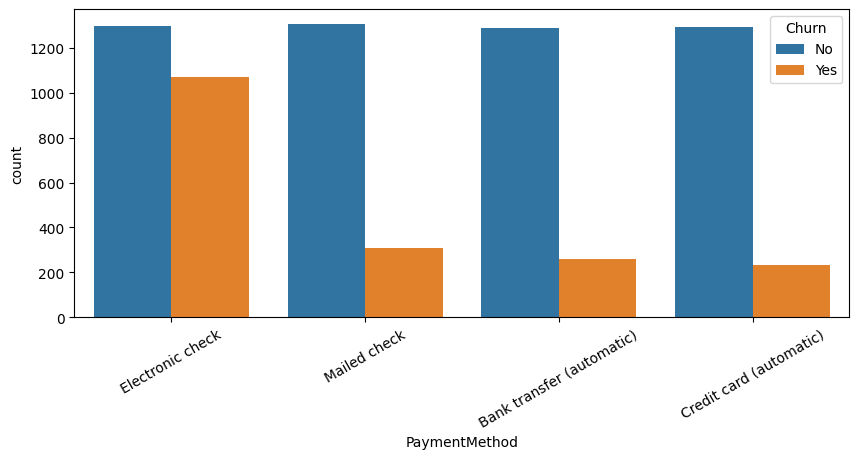

In [12]:
plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=30)

plt.show()

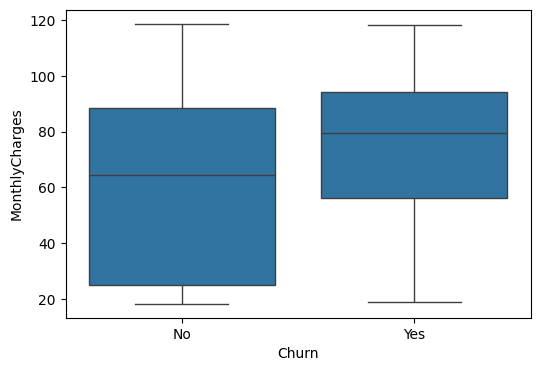

In [13]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.show()

In [14]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4-6 Years"
    ]
)

df[["tenure","tenure_group"]].head()

,tenure,tenure_group
0,1,0-1 Year
1,34,2-4 Years
2,2,0-1 Year
3,45,2-4 Years
4,2,0-1 Year


In [15]:
df["high_value_customer"] = np.where(
    df["MonthlyCharges"] > 70,
    "Yes",
    "No"
)

df[["MonthlyCharges","high_value_customer"]].head()

,MonthlyCharges,high_value_customer
0,29.85,No
1,56.95,No
2,53.85,No
3,42.30,No
4,70.70,Yes


In [16]:
service_cols = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["total_services"] = df[service_cols].apply(
    lambda row: sum(row=="Yes"),
    axis=1
)

df[["total_services"]].head()

,total_services
0,1
1,3
2,3
3,3
4,1


In [18]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

label_encoders = {}

for col in df_ml.columns:
    if df_ml[col].dtype == "object":
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

In [19]:
X = df_ml.drop("Churn", axis=1)

y = df_ml["Churn"]

print(X.shape)
print(y.shape)

(7043, 23)
(7043,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

ValueError: could not convert string to float: '4223-BKEOR'

In [22]:
print(X.dtypes)

customerID                  str
gender                      str
SeniorCitizen             int64
Partner                     str
Dependents                  str
tenure                    int64
PhoneService                str
MultipleLines               str
InternetService             str
OnlineSecurity              str
OnlineBackup                str
DeviceProtection            str
TechSupport                 str
StreamingTV                 str
StreamingMovies             str
Contract                    str
PaperlessBilling            str
PaymentMethod               str
MonthlyCharges          float64
TotalCharges            float64
tenure_group           category
high_value_customer         str
total_services            int64
dtype: object


In [23]:
print(X.select_dtypes(include=['object']).columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'high_value_customer'],
      dtype='str')


C:\Users\adith\AppData\Local\Temp\ipykernel_14384\775089586.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include=['object']).columns)


In [24]:
print(X_train.shape)
print(y_train.shape)

(5634, 23)
(5634,)


In [25]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

label_encoders = {}

for col in df_ml.columns:
    if df_ml[col].dtype == "object":
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

df_ml = df_ml.drop("customerID", axis=1)

In [26]:
X = df_ml.drop("Churn", axis=1)
y = df_ml["Churn"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

ValueError: could not convert string to float: 'Female'

In [29]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Drop customerID first
df_ml = df_ml.drop("customerID", axis=1)

# Convert all text/category columns to numbers
label_encoders = {}

for col in df_ml.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

df_ml.head()

C:\Users\adith\AppData\Local\Temp\ipykernel_14384\1168547982.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_ml.select_dtypes(include=["object", "category"]).columns:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,high_value_customer,total_services
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,2,29.85,29.85,0,0,0,1
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,0,2,0,3
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,108.15,1,0,0,3
3,1,0,0,0,45,0,1,0,2,0,...,0,1,0,0,42.30,1840.75,0,2,0,3
4,0,0,0,0,2,1,0,1,0,0,...,0,0,1,2,70.70,151.65,1,0,1,1


In [30]:
df_ml.select_dtypes(include=["object", "category"]).columns

Index([], dtype='str')

In [31]:
X = df_ml.drop("Churn", axis=1)
y = df_ml["Churn"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8026969481902059


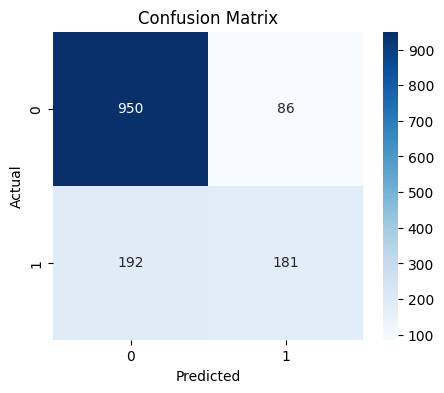

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
18,TotalCharges,0.169929
17,MonthlyCharges,0.160989
4,tenure,0.135006
14,Contract,0.073831
16,PaymentMethod,0.049091
19,tenure_group,0.041257
8,OnlineSecurity,0.040118
11,TechSupport,0.038187
21,total_services,0.036493
0,gender,0.027761


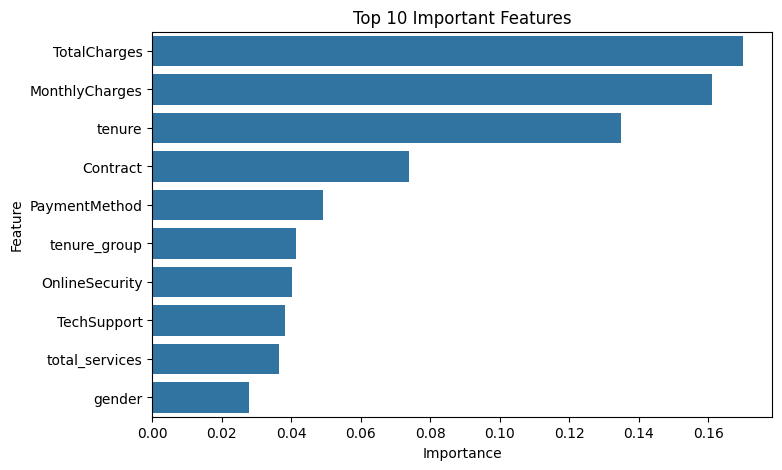

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [37]:
import pickle

In [38]:
with open("random_forest_churn_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model Saved")

Model Saved


In [39]:
with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

print("Encoders Saved")

Encoders Saved


In [40]:
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(list(X.columns), file)

print("Feature Columns Saved")

Feature Columns Saved
